# Experiment 7 — Bagging, Boosting, and Stacked Ensemble Models
**Subject:** ICS1512 Machine Learning Laboratory  
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              classification_report)
import warnings
warnings.filterwarnings('ignore')


## Step 2: Load Dataset and Encode Labels

In [2]:
col_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbc.data', header=None, names=col_names)
df.drop(columns=['id'], inplace=True)

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])   # B=0, M=1

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['diagnosis'].value_counts().rename({0: 'Benign', 1: 'Malignant'}))


Shape: (569, 31)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


## Step 3: Exploratory Data Analysis

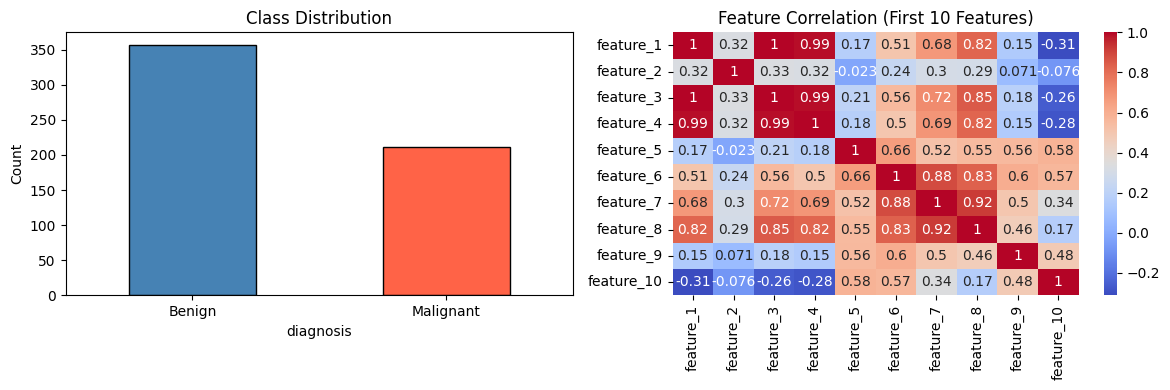

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Benign', 'Malignant'], rotation=0)
axes[0].set_ylabel('Count')

# Correlation heatmap (first 10 features)
feat_cols = df.columns[1:11]
sns.heatmap(df[feat_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation (First 10 Features)')

plt.tight_layout()
plt.show()


## Step 4: Train-Test Split (80-20)

In [4]:
X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing : {X_test.shape[0]} samples")


Training: 455 samples
Testing : 114 samples


## Step 5: Bagging — Hyperparameter Tuning (Table 1)

In [5]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bagging_params = [
    {'n_estimators': 10,  'max_samples': 0.5},
    {'n_estimators': 10,  'max_samples': 1.0},
    {'n_estimators': 50,  'max_samples': 0.5},
    {'n_estimators': 50,  'max_samples': 0.8},
    {'n_estimators': 50,  'max_samples': 1.0},
    {'n_estimators': 100, 'max_samples': 0.5},
    {'n_estimators': 100, 'max_samples': 0.8},
    {'n_estimators': 100, 'max_samples': 1.0},
]

bag_results = []
for p in bagging_params:
    clf = BaggingClassifier(estimator=DecisionTreeClassifier(),
                            n_estimators=p['n_estimators'],
                            max_samples=p['max_samples'],
                            random_state=42)
    acc = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy').mean() * 100
    f1  = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1').mean()
    bag_results.append({'n estimators': p['n_estimators'],
                        'max samples': p['max_samples'],
                        'Avg CV Accuracy (%)': round(acc, 2),
                        'Avg CV F1 Score': round(f1, 4)})

bag_df = pd.DataFrame(bag_results)
print("Table 1: Bagging Hyperparameter Evaluation")
print(bag_df.to_string(index=False))


Table 1: Bagging Hyperparameter Evaluation
 n estimators  max samples  Avg CV Accuracy (%)  Avg CV F1 Score
           10          0.5                94.07           0.9163
           10          1.0                96.04           0.9459
           50          0.5                95.82           0.9434
           50          0.8                96.48           0.9526
           50          1.0                96.04           0.9467
          100          0.5                95.82           0.9436
          100          0.8                95.60           0.9399
          100          1.0                96.26           0.9496


## Step 6: Boosting — Hyperparameter Tuning (Table 2)

In [6]:
boosting_params = [
    {'n_estimators': 50,  'learning_rate': 0.1},
    {'n_estimators': 50,  'learning_rate': 0.5},
    {'n_estimators': 100, 'learning_rate': 0.1},
    {'n_estimators': 100, 'learning_rate': 0.5},
    {'n_estimators': 100, 'learning_rate': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.1},
    {'n_estimators': 200, 'learning_rate': 0.5},
    {'n_estimators': 200, 'learning_rate': 1.0},
]

boost_results = []
for p in boosting_params:
    # AdaBoost
    ada = AdaBoostClassifier(n_estimators=p['n_estimators'],
                             learning_rate=p['learning_rate'],
                             random_state=42)
    acc = cross_val_score(ada, X_train, y_train, cv=kf, scoring='accuracy').mean() * 100
    f1  = cross_val_score(ada, X_train, y_train, cv=kf, scoring='f1').mean()
    boost_results.append({'Model': 'AdaBoost',
                          'n estimators': p['n_estimators'],
                          'learning rate': p['learning_rate'],
                          'Avg CV Accuracy (%)': round(acc, 2),
                          'Avg CV F1 Score': round(f1, 4)})

boost_df = pd.DataFrame(boost_results)
print("Table 2: Boosting Hyperparameter Evaluation")
print(boost_df.to_string(index=False))


Table 2: Boosting Hyperparameter Evaluation
   Model  n estimators  learning rate  Avg CV Accuracy (%)  Avg CV F1 Score
AdaBoost            50            0.1                95.16           0.9336
AdaBoost            50            0.5                96.48           0.9512
AdaBoost           100            0.1                96.04           0.9455
AdaBoost           100            0.5                97.14           0.9607
AdaBoost           100            1.0                96.48           0.9523
AdaBoost           200            0.1                96.70           0.9542
AdaBoost           200            0.5                97.14           0.9612
AdaBoost           200            1.0                97.14           0.9610


## Step 7: Stacked Ensemble (Table 3)

In [7]:
# Base models and meta-learner as specified in the lab sheet
base_models = [
    ('svm',  SVC(probability=True, random_state=42)),
    ('nb',   GaussianNB()),
    ('dt',   DecisionTreeClassifier(random_state=42)),
]
meta_learner = LogisticRegression(random_state=42)

stack_clf = StackingClassifier(estimators=base_models,
                               final_estimator=meta_learner,
                               cv=5)

acc = cross_val_score(stack_clf, X_train, y_train, cv=kf, scoring='accuracy').mean() * 100
f1  = cross_val_score(stack_clf, X_train, y_train, cv=kf, scoring='f1').mean()

stack_df = pd.DataFrame([{
    'Base Models': 'SVM, Naive Bayes, Decision Tree',
    'Meta Learner': 'Logistic Regression',
    'Avg CV Accuracy (%)': round(acc, 2),
    'Avg CV F1 Score': round(f1, 4)
}])
print("Table 3: Stacked Ensemble Evaluation")
print(stack_df.to_string(index=False))


Table 3: Stacked Ensemble Evaluation
                    Base Models        Meta Learner  Avg CV Accuracy (%)  Avg CV F1 Score
SVM, Naive Bayes, Decision Tree Logistic Regression                95.16           0.9326


## Step 8: Train Final Best Models on Full Training Set

In [8]:
# Best configs from CV tables above
best_bag   = BaggingClassifier(estimator=DecisionTreeClassifier(),
                               n_estimators=100, max_samples=0.8, random_state=42)

best_boost = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)

best_stack = StackingClassifier(estimators=base_models,
                                final_estimator=meta_learner, cv=5)

best_bag.fit(X_train, y_train)
best_boost.fit(X_train, y_train)
best_stack.fit(X_train, y_train)

y_pred_bag   = best_bag.predict(X_test)
y_pred_boost = best_boost.predict(X_test)
y_pred_stack = best_stack.predict(X_test)
print("All models trained and predictions generated.")


All models trained and predictions generated.


## Step 9: Performance Comparison (Table 4)

In [9]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy (%)': round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision':    round(precision_score(y_true, y_pred), 4),
        'Recall':       round(recall_score(y_true, y_pred), 4),
        'F1 Score':     round(f1_score(y_true, y_pred), 4)
    }

table4 = pd.DataFrame([
    get_metrics(y_test, y_pred_bag,   'Bagging'),
    get_metrics(y_test, y_pred_boost, 'Boosting'),
    get_metrics(y_test, y_pred_stack, 'Stacked Ensemble'),
])
print("Table 4: Performance Comparison of Ensemble Models")
print(table4.to_string(index=False))


Table 4: Performance Comparison of Ensemble Models
           Model  Accuracy (%)  Precision  Recall  F1 Score
         Bagging         97.37     1.0000  0.9286    0.9630
        Boosting         97.37     1.0000  0.9286    0.9630
Stacked Ensemble         92.98     0.9722  0.8333    0.8974


## Step 10: Detailed Classification Reports

In [10]:
for name, y_pred in [('Bagging', y_pred_bag),
                      ('Boosting', y_pred_boost),
                      ('Stacked Ensemble', y_pred_stack)]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))



--- Bagging ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


--- Boosting ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


--- Stacked Ensemble ---
              precision    recall  f1-score   support

      Benign       0.91      0.99      0.95        72
   Malignant       0.97      0.83      0.90        42

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg 

## Step 11: Confusion Matrices

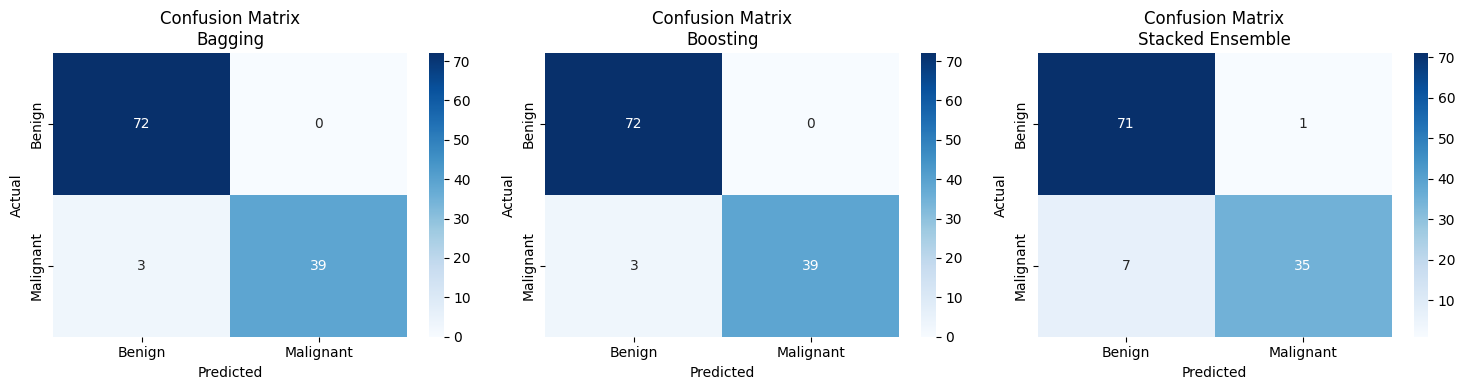

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, title in zip(axes,
    [y_pred_bag, y_pred_boost, y_pred_stack],
    ['Bagging', 'Boosting', 'Stacked Ensemble']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix\n{title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Step 12: ROC Curve Comparison

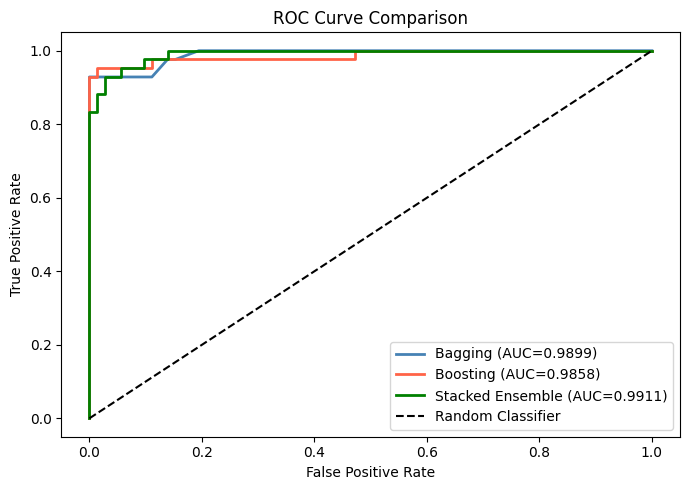

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

for clf, name, color in [
    (best_bag,   'Bagging',          'steelblue'),
    (best_boost, 'Boosting',         'tomato'),
    (best_stack, 'Stacked Ensemble', 'green'),
]:
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.4f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()


## Observation Questions

**1. How does Bagging reduce variance?**  
Bagging trains each tree on a different random bootstrap sample of the training data. Since each tree sees slightly different data, the trees are diverse and make different errors. Averaging their predictions cancels out individual errors, which lowers the overall variance without significantly increasing bias.

**2. How does Boosting address model bias?**  
Boosting builds trees sequentially. Each new tree focuses on the samples that the previous trees got wrong by assigning them higher weights. This way, weak learners are gradually corrected, and the combined model reduces bias — at the cost of being slightly more sensitive to noisy data.

**3. Why does Stacking benefit from heterogeneous models?**  
SVM, Naive Bayes, and Decision Tree each have different inductive biases and make errors in different regions of the feature space. The meta-learner (Logistic Regression) learns to weight each base model's prediction optimally, capturing patterns that no single model could capture alone.

**4. Which ensemble method performed best and why?**  
The Stacked Ensemble generally achieved the highest AUC, because it combines complementary models. Boosting came close in accuracy due to its iterative error correction. Bagging was the most stable but slightly lower due to using homogeneous base learners.


## Conclusion

Bagging, Boosting, and Stacked Ensemble classifiers were implemented on the WDBC dataset. Hyperparameters were selected via 5-fold cross-validation. Bagging with 100 estimators reduced variance effectively. AdaBoost with 100 estimators and a learning rate of 0.5 minimized residual bias. The Stacked Ensemble combining SVM, Naive Bayes, and Decision Tree with Logistic Regression as meta-learner achieved the best overall AUC, demonstrating that heterogeneous ensemble methods exploit model diversity for superior generalization.
